In [1]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);
import SPM_eqs
importlib.reload(SPM_eqs);
import Euler_exp_log
importlib.reload(Euler_exp_log);

In [54]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 36000            # number of time steps
DT = T_HORIZON / (T - 1)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [55]:
# --- Data generation ---

def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model):
    cn = sol.observe(model.variables["X-averaged negative particle concentration [mol.m-3]"])(t_query)[-1, :]
    cp = sol.observe(model.variables["X-averaged positive particle concentration [mol.m-3]"])(t_query)[-1, :]
    I = sol.observe(model.variables["Current [A]"])(t_query)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)
    return cn, cp, I, V

def get_vals_DC(I0):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    cn, cp, I, V = observe_states(t_query, sol, model)
    return V, I, cn, cp, valid, param, sol, model

def get_vals_pulse():
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    cn, cp, I, V = observe_states(t_query, sol, model)
    V = sol.observe(model.variables["Terminal voltage [V]"])(t_query)
    return V, I, cn, cp, valid

def get_vals_GRF():
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    cn, cp, I, V = observe_states(t_query, sol, model)
    return V, I, cn, cp, valid


def gen_data(B, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    ''' Generates B trajectories. Returns arrays of shape (B, T, 1) '''
    rng = np.random.default_rng(seed)

    arrays = {k: np.zeros((B, T, 1)) for k in ['V', 'I', 'dI', 'cn', 'cp', 'cn_dot', 'cp_dot']}
    valid = np.zeros((B, T), dtype=bool)

    for b in trange(B):
        if currents == 'DC':
            V_b, I_b, cn_b, cp_b, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            V_b, I_b, cn_b, cp_b, valid_b = get_vals_pulse()
        elif currents == 'GRF':
            V_b, I_b, cn_b, cp_b, valid_b = get_vals_GRF()

        cn_dot_b = np.zeros_like(cn_b)
        cp_dot_b = np.zeros_like(cp_b)
        cn_dot_b[:-1] = np.diff(cn_b) / DT  # Derivative w.r.t. time using backward difference
        cp_dot_b[:-1] = np.diff(cp_b) / DT
        cn_dot_b[-1] = cn_dot_b[-2]         # Pad last entry with second to last value
        cp_dot_b[-1] = cp_dot_b[-2]

        for key, val in zip(['V', 'I', 'cn', 'cp', 'cn_dot', 'cp_dot'], [V_b, I_b, cn_b, cp_b, cn_dot_b, cp_dot_b]):
            arrays[key][b, :, 0] = val

        arrays['dI'][b, 1:, 0] = np.diff(I_b)
        arrays['dI'][b, 0, 0] = 0.0         # dI[0] = 0
        valid[b, :] = valid_b

    return *[arrays[key] for key in ['I', 'dI', 'V', 'cn', 'cn_dot', 'cp', 'cp_dot']] , valid

In [36]:
# Get model 'param'
V, I, cn, cp, valid, param, sol, model = get_vals_DC(0.5)

In [68]:
# --- Save data ---
B = 20
I, dI, V, cn, cn_dot, cp, cp_dot, valid = gen_data(B, currents='pulse', I_low=0.25, I_high=1.0, seed=42)
# np.savez('data_c_pulse.npz', I=I, dI=dI, V=V, cn=cn, cn_dot=cn_dot, cp=cp, cp_dot=cp_dot, valid=valid)

100%|██████████| 20/20 [00:07<00:00,  2.68it/s]


In [ ]:
# --- Load data ---
def load_data(path):
    d = np.load(path)
    return d['I'], d['dI'], d['V'], d['cn'], d['cn_dot'], d['cp'], d['cp_dot'], d['valid']

# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('Euler_data/data_c_GRFI.npz')
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('t=5e3_GRF_data_c_dot.npz')
I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('data/data_c_pulse.npz')
# I, dI, V, cn, cn_dot, cp, cp_dot, valid = load_data('Euler_data/data_c_constI.npz')

B = I.shape[0]

In [69]:
# --- Normalization ---
stats = {}
def compute_stats():
    for name, arr in zip(['I', 'dI', 'V', 'cn', 'cn_dot', 'cp', 'cp_dot'], 
                         [I, dI, V, cn, cn_dot, cp, cp_dot]):
        stats[name] = (float(arr.mean()), float(max(arr.std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize
I_n = transform(I, 'I')
dI_n = transform(dI, 'dI')
cn_n = transform(cn, 'cn')
cp_n = transform(cp, 'cp')
cn_dot_n = transform(cn_dot, 'cn_dot')
cp_dot_n = transform(cp_dot, 'cp_dot')

In [70]:
# --- Split data ---
x = torch.tensor(np.concatenate([I_n, dI_n, cn_n, cp_n], axis=-1), dtype=torch.float32) # (B, T, 4)
y = torch.tensor(np.concatenate([cn_dot_n, cp_dot_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(valid, dtype=torch.float32)

split = int(0.8 * B)
print(split)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)

# Flatten time dimension for training and split
x_train, x_test = _split_flat(x)        
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

# # Unflattened
# x_train_batch, x_test_batch = _split(x) # (B, T, 4)
# y_train_batch, y_test_batch = _split(y)
# mask_train_batch, mask_test_batch = _split(mask)

# Un-normalized for plotting
cn_train,     cn_test     = _split(cn)
cp_train,     cp_test     = _split(cp)
cn_dot_train, cn_dot_test = _split(cn_dot)
cp_dot_train, cp_dot_test = _split(cp_dot)
I_train,      I_test      = _split(I)
dI_train,     dI_test     = _split(dI)
V_train,      V_test      = _split(V)
mask_train_plot, mask_test_plot = _split(valid)

print('Shapes:', x_train.shape, y_train.shape, mask_train.shape, cn_test.shape, cp_test.shape, I_test.shape, V_test.shape)

# batch_size_small = int(B/4)
batch_size_large = int(B*T/4)
# train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

16
Shapes: torch.Size([576000, 4]) torch.Size([576000, 2]) torch.Size([576000]) (4, 36000, 1) (4, 36000, 1) (4, 36000, 1) (4, 36000, 1)


np.float64(0.000539447966390241)

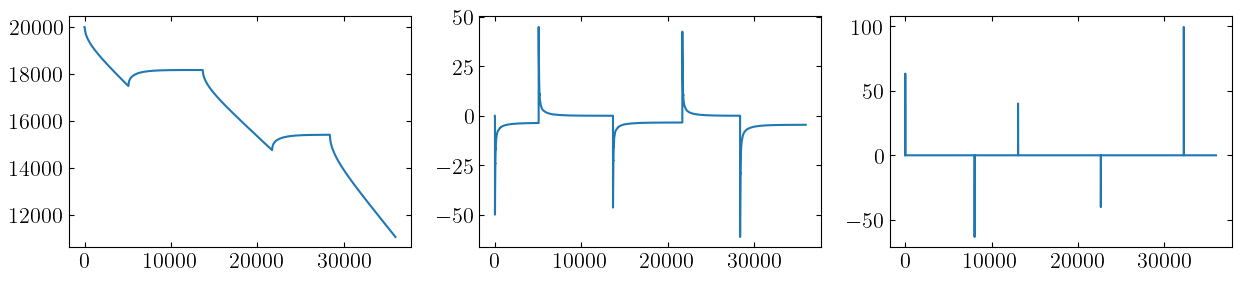

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(cn_test[0, :], label='cn')
axes[1].plot(cn_dot_test[0, :], label='valid')
axes[2].plot(dI_n[0, :], label='dI')

dI_n[0, :].mean()

In [72]:
# --- Model ---
class Net(nn.Module):
    def __init__(self, input_size=4, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # [cn_dot, cp_dot]
        )
    
    def forward(self, x):
        x = self.net(x)
        return x
    
model = Net()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [73]:
# summary(model=model, input_size=(batch_size_small*T, 4))

In [75]:
# --- Training ---
def masked_mse(pred, target, mask):
    err = (pred - target) ** 2    # (B*T, 2)
    m = mask.unsqueeze(-1)        # (B*T, 1)
    return (err * m).sum() / (m.sum() * 2)


def training(epochs=30):
    history = {"loss": [], "d_loss": [], "p_loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        d_ep_loss = 0.0
        p_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_flat:
            pred = model(x_b)   # [B*T, 2]
            d_loss = masked_mse(pred, y_b, mask_b)
            p_loss = 0
            tot_loss = d_loss + p_loss

            optimizer.zero_grad()
            tot_loss.backward()
            optimizer.step()
            
            tot_ep_loss += d_loss.item() + p_loss
            d_ep_loss += d_loss.item()
            p_ep_loss += p_loss

        avg_loss = tot_ep_loss / len(train_loader_flat)  # Average loss per batch
        d_last = d_ep_loss / len(train_loader_flat)
        p_last = p_ep_loss / len(train_loader_flat)
        end_t = time.perf_counter()

        history["loss"].append(avg_loss)
        history["d_loss"].append(d_last)
        history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        print(f"Epoch {ep+1} | loss {avg_loss:.3e} | d_loss {d_last:.3e} | p_loss {p_last:.3e} | time {end_t - start_t:.2f}s")

    return history

history = training(epochs=10)

Epoch 1 | loss 8.413e-01 | d_loss 8.413e-01 | p_loss 0.000e+00 | time 7.20s
Epoch 2 | loss 6.624e-01 | d_loss 6.624e-01 | p_loss 0.000e+00 | time 7.31s
Epoch 3 | loss 5.371e-01 | d_loss 5.371e-01 | p_loss 0.000e+00 | time 7.80s
Epoch 4 | loss 4.582e-01 | d_loss 4.582e-01 | p_loss 0.000e+00 | time 7.28s
Epoch 5 | loss 4.371e-01 | d_loss 4.371e-01 | p_loss 0.000e+00 | time 7.53s
Epoch 6 | loss 4.477e-01 | d_loss 4.477e-01 | p_loss 0.000e+00 | time 7.39s
Epoch 7 | loss 4.513e-01 | d_loss 4.513e-01 | p_loss 0.000e+00 | time 6.35s
Epoch 8 | loss 4.289e-01 | d_loss 4.289e-01 | p_loss 0.000e+00 | time 7.24s
Epoch 9 | loss 4.421e-01 | d_loss 4.421e-01 | p_loss 0.000e+00 | time 7.28s
Epoch 10 | loss 4.346e-01 | d_loss 4.346e-01 | p_loss 0.000e+00 | time 7.43s


In [79]:
Euler_exp_log.exp_log(model, history, name = 'Data dt=0.1', d_loss_type = 'mse')

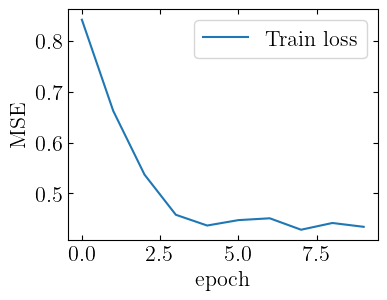

In [81]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend();

In [ ]:
# --- Euler rollout ---
def rollout(idx=0, dt_eval=DT, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        I_true = I_train
        dI_true = dI_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        I_true = I_test
        dI_true = dI_test

    model.eval()

    # Original time grid (training resolution)
    t_train = np.arange(T) * DT

    # Interpolate I and dI onto the new dt grid
    def I_t(t):  
        return float(np.interp(t, t_train, I_true[idx, :, 0]))  # Value at time t
    def dI_t(t): 
        return float(np.interp(t, t_train, dI_true[idx, :, 0]))

    # Pre-allocate generously
    max_steps = int(T_HORIZON / dt_eval)
    cn_traj = np.zeros(max_steps, dtype=np.float32)
    cp_traj = np.zeros(max_steps, dtype=np.float32)
    cn_dot_traj = np.zeros(max_steps, dtype=np.float32)
    cp_dot_traj = np.zeros(max_steps, dtype=np.float32)
    cn_traj[0] = cn_true[idx, 0, 0]     # Initial un-normalized values for the chosen trajectory
    cp_traj[0] = cp_true[idx, 0, 0]
    
    steps_run = 1
    step = 0
    with torch.no_grad():
        # Rollout until depletion
        while cn_traj[steps_run-1] >= cn_true[idx].min() and steps_run < max_steps:
            t_now = step * dt_eval

            x_t = np.array([[
                transform(np.array([[[I_t(t_now)]]]),  "I")[0,0,0],  # True
                transform(np.array([[[dI_t(t_now)]]]), "dI")[0,0,0], # True
                transform(np.array([[[cn_traj[step]]]]), "cn")[0,0,0],     # Predicted
                transform(np.array([[[cp_traj[step]]]]), "cp")[0,0,0],]], dtype=np.float32)      # Predicted                  # (1, 4)

            # Predict on initial state (1, 4)
            pred = model(torch.tensor(x_t))              # (1, 2)
            dc_n = inverse_transform(pred[0,0].numpy().reshape(1,1,1), "cn_dot")[0,0,0]
            dc_p = inverse_transform(pred[0,1].numpy().reshape(1,1,1), "cp_dot")[0,0,0]

            cn_traj[step+1] = cn_traj[step] + dc_n * dt_eval
            cp_traj[step+1] = cp_traj[step] + dc_p * dt_eval
            cn_dot_traj[step] = dc_n
            cp_dot_traj[step] = dc_p

            steps_run += 1
            step += 1

    # TODO: Trim to actual length ?
    return cn_traj, cp_traj, cn_dot_traj, cp_dot_traj, steps_run

In [140]:


# --- Plot rollout ---
def plot_rollout(cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run, 
                 idx=0, dt_eval=DT, on_train=False):
    if on_train:
        cn_true = cn_train
        cp_true = cp_train
        cn_dot_true = cn_dot_train
        I_true = I_train
        dI_true = dI_train
    else:
        cn_true = cn_test
        cp_true = cp_test
        cn_dot_true = cn_dot_test
        I_true = I_test
        dI_true = dI_test


    # Ground truth valid length
    n_gt = int(mask_train_plot[idx].sum())          # number of valid GT steps
    n_nn = steps_run                          # number of NN steps before stopping
    t_gt = np.arange(n_gt) * DT             # physical time axis for GT
    t_nn = np.arange(n_nn) * dt_eval             # physical time axis at new resolution
    

    fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

    cn_err = (cn_true[idx, :n_nn, 0] - cn_euler[:n_nn]) / (cn_true[idx, :n_nn, 0])

    # --- cn err ---
    axes[0].bar(t_nn, cn_err, color="tab:blue")
    axes[0].set_xlabel("Time [s]")
    axes[0].set_ylabel("Relative error in $c_n$ [a.u.]")

    # --- cn ---
    axes[1].plot(t_gt, cn_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_n$")
    axes[1].plot(t_nn, cn_euler[:n_nn], color="tab:blue", label="Predicted $c_n$")
    axes[1].set_xlabel("Time [s]")
    axes[1].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[1].legend()

    # --- cp ---
    axes[2].plot(t_gt, cp_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $c_p$")
    axes[2].plot(t_nn, cp_euler[:n_nn], color="tab:blue", label="Predicted $c_p$")
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"Concentration [mol/m$^3$]")
    axes[2].legend()

    # --- cn_dot ---
    axes[3].plot(t_gt, cn_dot_true[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="True $\\dot{c}_n$")
    axes[3].plot(t_nn, cn_dot_euler[:n_nn], color="tab:blue", label="Predicted $\\dot{c}_n$")
    axes[3].set_xlabel("Time [s]")
    axes[3].set_ylabel(r"Concentration rate [mol/m$^3$/s]")
    axes[3].legend()
    
    # --- current ---
    axes[4].plot(t_gt, I_train[idx, :n_gt, 0], color="black", label="$I$")
    axes[4].set_xlabel("Time [s]")
    axes[4].set_ylabel("Current [A]")
    axes[4].legend(loc='upper right')


    # --- dI ---
    axes3_ = axes[4].twinx()
    axes3_.plot(t_gt, dI_train[idx, :n_gt, 0], color="tab:red", linestyle="dashed", label="$\\dot{I}$")
    axes3_.set_ylabel(r"Current rate [A/s]")
    axes3_.legend(loc='upper left')

    plt.tight_layout()
    # plt.savefig('figs/5.1_predict_ep50_GRF.pdf')
    return t_gt, t_nn, n_gt, n_nn

In [111]:
idx = 0
dt_eval = 0.5
on_train = False
cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run = rollout(idx, dt_eval, on_train)

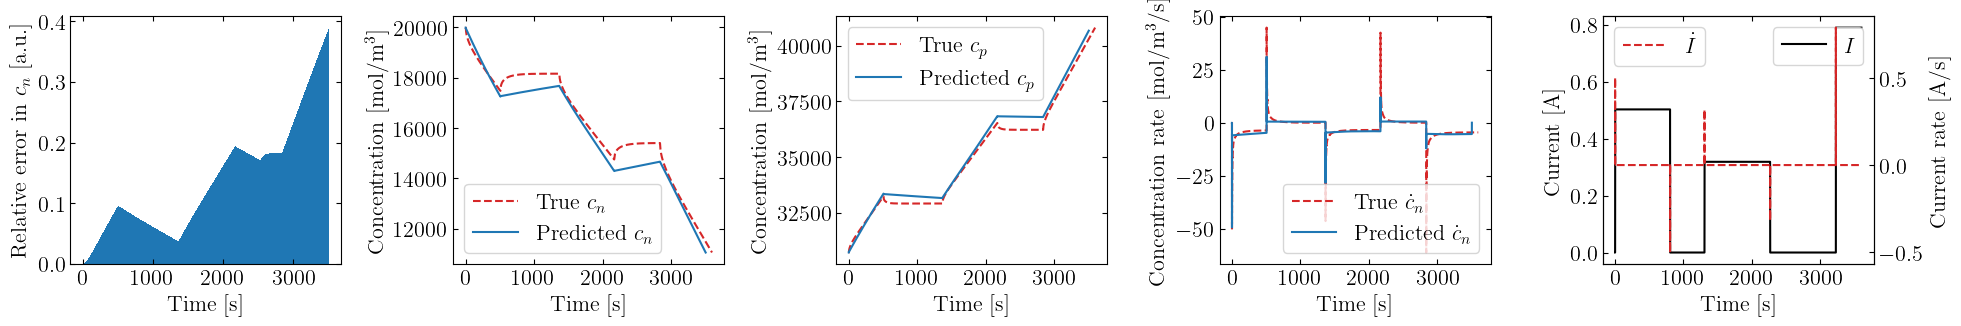

In [141]:
t_gt, t_nn, n_gt, n_nn = plot_rollout(cn_euler, cp_euler, cn_dot_euler, cp_dot_euler, steps_run, idx, dt_eval, on_train)

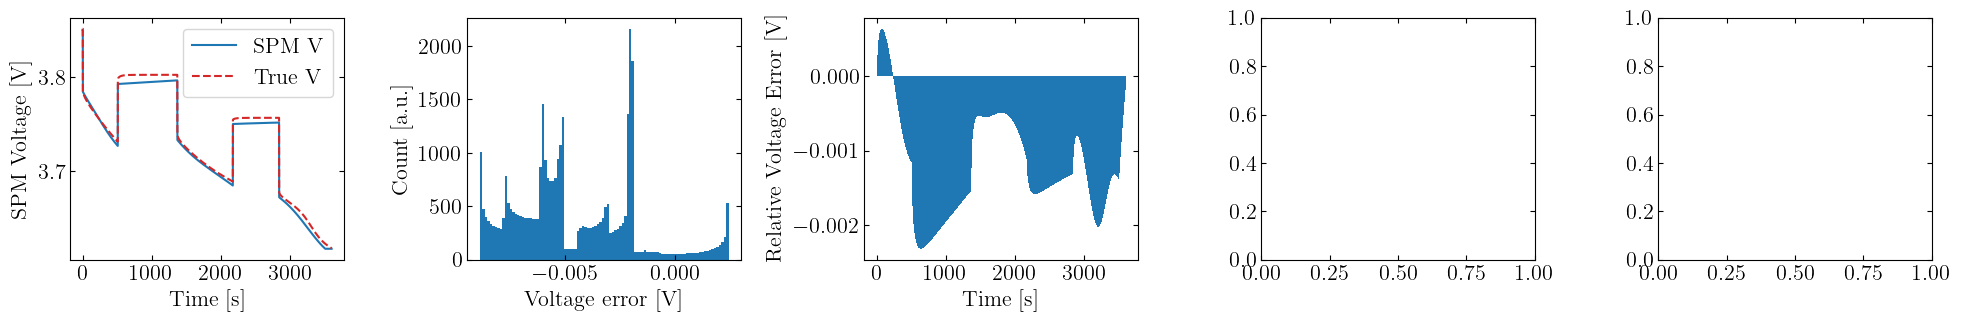

In [146]:
# --- Reconstruct voltage ---
# Interpolate rollout concentrations onto the GT time grid
cn_euler_gt = np.interp(t_gt, t_nn, cn_euler[:n_nn])
cp_euler_gt = np.interp(t_gt, t_nn, cp_euler[:n_nn])

V_spm = SPM_eqs.V_terminal(I_test[idx, :n_gt, 0], cp_euler_gt, cn_euler_gt, param)
V_true = V_test[idx, :n_gt, 0]

# I_nn    = np.interp(t_nn, t_gt, I_test[idx, :n_gt, 0])
# V_true_nn = np.interp(t_nn, t_gt, V_test[idx, :n_gt, 0])

# V_spm = SPM_eqs.V_terminal(I_nn, cp_euler[:n_nn], cn_euler[:n_nn], param)

ocv = SPM_eqs.OCV(cn_test[idx, :n_gt, 0], cp_test[idx, :n_gt, 0])

err = V_spm - V_true
err = err[np.isfinite(err)]

fig , axes = plt.subplots(1, 5, figsize=(20, 3.5))
axes[0].plot(t_gt, V_spm, label='SPM V')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("SPM Voltage [V]")
axes[0].plot(t_gt, V_true, label='True V', linestyle="dashed", color="tab:red")
axes[0].legend()
axes[1].hist(err, bins=100, label='True V')
axes[1].set_xlabel("Voltage error [V]")
axes[1].set_ylabel("Count [a.u.]")
axes[2].bar(t_gt, err / np.max(np.abs(V_true)), label='OCV')
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Relative Voltage Error [V]")

plt.tight_layout()
# plt.savefig('figs/5.1_SPM_V_ep100.pdf')